In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [141]:
data = pd.read_csv('train.csv',usecols=["X1","X2","X3","X4","X5","X6"])
data.head()

,X1,X2,X3,X4,X5,X6
0,v,at,a,d,u,j
1,t,av,e,d,y,l
2,w,n,c,d,x,j
3,t,n,f,d,x,l
4,v,n,f,d,h,d


In [142]:
#lets understand that at how many labels each variables have
for col in data.columns:
    print(col,':',len(data[col].unique()),'labels')

X1 : 27 labels
X2 : 44 labels
X3 : 7 labels
X4 : 4 labels
X5 : 29 labels
X6 : 12 labels


In [143]:
#Lets examine how many columns we will obtain one hot encoding these variables
pd.get_dummies(data,drop_first=True).shape

(4209, 117)

In [144]:
#Lets find top 10 most frequest categories for the variable
data.X2.value_counts().sort_values(ascending=False).head(20)

X2
as    1659
ae     496
ai     415
m      367
ak     265
r      153
n      137
s       94
f       87
e       81
aq      63
ay      54
a       47
t       29
k       25
i       25
b       21
ao      20
z       19
ag      19
Name: count, dtype: int64

In [145]:
#lets make a list with the most frequents categories of the variable
top_10 = [x for x in data.X2.value_counts().sort_values(ascending = False).head(10).index]
top_10

['as', 'ae', 'ai', 'm', 'ak', 'r', 'n', 's', 'f', 'e']

In [146]:
#and now we make 10 binary variable
for label in top_10:
    data[label] = np.where(data['X2'] == label,1,0)
data[['X2']+top_10].head(40)

,X2,as,ae,ai,m,ak,r,n,s,f,e
0,at,0,0,0,0,0,0,0,0,0,0
1,av,0,0,0,0,0,0,0,0,0,0
2,n,0,0,0,0,0,0,1,0,0,0
3,n,0,0,0,0,0,0,1,0,0,0
4,n,0,0,0,0,0,0,1,0,0,0
5,e,0,0,0,0,0,0,0,0,0,1
6,e,0,0,0,0,0,0,0,0,0,1
7,as,1,0,0,0,0,0,0,0,0,0
8,as,1,0,0,0,0,0,0,0,0,0
9,aq,0,0,0,0,0,0,0,0,0,0


In [147]:
#get whole set of dummy variable ,for all the categorical variable
def one_hot_top_x(df,variable,top_10):

 #function to create the dummy variable for the most frequent labels
 # we can vary the number of most frequent labels that we encode
   for label in top_10:
      df[variable+'_'+label] = np.where(data[variable] == label,1,0)

#read the data again
data = pd.read_csv('train.csv',usecols=["X1","X2","X3","X4","X5","X6"])

#encode X2 into the 10 most frequent categories
one_hot_top_x(data,'X2','top_10')
data.head()
 

 

,X1,X2,X3,X4,X5,X6,X2_t,X2_o,X2_p,X2__,X2_1,X2_0
0,v,at,a,d,u,j,0,0,0,0,0,0
1,t,av,e,d,y,l,0,0,0,0,0,0
2,w,n,c,d,x,j,0,0,0,0,0,0
3,t,n,f,d,x,l,0,0,0,0,0,0
4,v,n,f,d,h,d,0,0,0,0,0,0


In [148]:
#find the 10 most frequent categories for x1
top_10 = [x for x in data.X1.value_counts().sort_values(ascending=False).head(10).index]

one_hot_top_x(data,'X1',top_10)
data.head()


,X1,X2,X3,X4,X5,X6,X2_t,X2_o,X2_p,X2__,...,X1_aa,X1_s,X1_b,X1_l,X1_v,X1_r,X1_i,X1_a,X1_c,X1_o
0,v,at,a,d,u,j,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,t,av,e,d,y,l,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,w,n,c,d,x,j,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,t,n,f,d,x,l,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,v,n,f,d,h,d,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [149]:
df = pd.read_csv('train.csv',usecols=['X1','X2'])
df.head()

,X1,X2
0,v,at
1,t,av
2,w,n
3,t,n
4,v,n


In [150]:
df.shape

(4209, 2)

One Hot Encoding

In [151]:
pd.get_dummies(df).shape

(4209, 71)

In [152]:
len(df['X1'].unique())

27

In [153]:
len(df['X2'].unique())

44

In [154]:
#lets have a look on how many labels
for col in df.columns:
    print(col,':',len(df[col].unique()),'labels')


X1 : 27 labels
X2 : 44 labels


In [155]:
#lets obtain the counts for each one of the labels in variable X2
#lets capture this in a dictionary that we can use to remap the labels
df.X2.value_counts().to_dict()

{'as': 1659,
 'ae': 496,
 'ai': 415,
 'm': 367,
 'ak': 265,
 'r': 153,
 'n': 137,
 's': 94,
 'f': 87,
 'e': 81,
 'aq': 63,
 'ay': 54,
 'a': 47,
 't': 29,
 'k': 25,
 'i': 25,
 'b': 21,
 'ao': 20,
 'z': 19,
 'ag': 19,
 'd': 18,
 'ac': 13,
 'g': 12,
 'ap': 11,
 'y': 11,
 'x': 10,
 'aw': 8,
 'at': 6,
 'h': 6,
 'q': 5,
 'al': 5,
 'an': 5,
 'av': 4,
 'p': 4,
 'ah': 4,
 'au': 3,
 'am': 1,
 'j': 1,
 'af': 1,
 'l': 1,
 'aa': 1,
 'c': 1,
 'o': 1,
 'ar': 1}

In [156]:
#and Now replace each label  in x2 by its count 
df_frequency_map = df.X2.value_counts().to_dict()

In [157]:
#and now we replace X2 labels in the dataset df
df.X2 = df.X2.map(df_frequency_map)
df.head(100)

,X1,X2
0,v,6
1,t,4
2,w,137
3,t,137
4,v,137
...,...,...
95,b,367
96,l,1659
97,aa,1659
98,b,367


Handling missing values --- features engineering

What are different types of Missing Data?

Missing Completly at random

In [158]:
# Missing Completly at Random, MCAR:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [159]:
#for finding missing number
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [160]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


2.Missing Data not at Rndom(MNAR):Systematic missing values

In [161]:
df['Cabin']


0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object

In [162]:
df['Cabin_null'] = np.where(df['Cabin'].isnull(),1,0)

##find the percentage of null values
df['Cabin_null'].mean()



np.float64(0.7710437710437711)

In [163]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Cabin_null'],
      dtype='object')

In [164]:
df.groupby(['Survived'])['Cabin_null'].mean()

Survived
0    0.876138
1    0.602339
Name: Cabin_null, dtype: float64

Missing at Random

All techniques of handling missing values

In [165]:
df = pd.read_csv('Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [166]:
## lets go and see percentage of missing number
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [167]:
def impute_nan(df,variable,median):
    df[variable+'_median'] = df[variable].fillna(median)


In [168]:
median = df.Age.median()
median   

28.0

In [169]:
impute_nan(df,'Age',median)
df.head()

,Survived,Age,Fare,Age_median
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [170]:
print(df['Age'].std())
print(df['Age_median'].std())

14.526497332334044
13.019696550973194


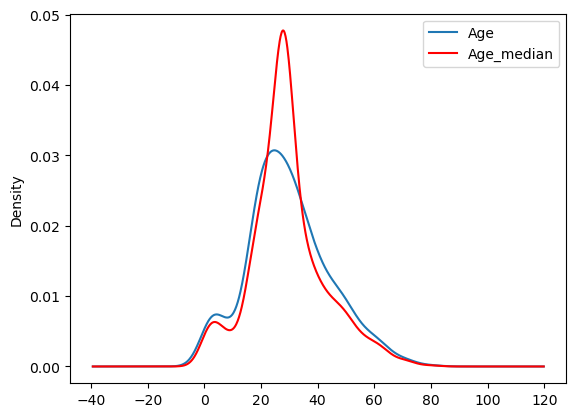

In [171]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind = 'kde',ax = ax)
df.Age_median.plot(kind = 'kde',ax = ax,color = 'red')
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc = 'best')

plt.show()




In [172]:
bigmart = pd.read_csv('Train_bm_bignart.csv')

In [173]:
bigmart.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type'],
      dtype='object')

item visibility Visualization

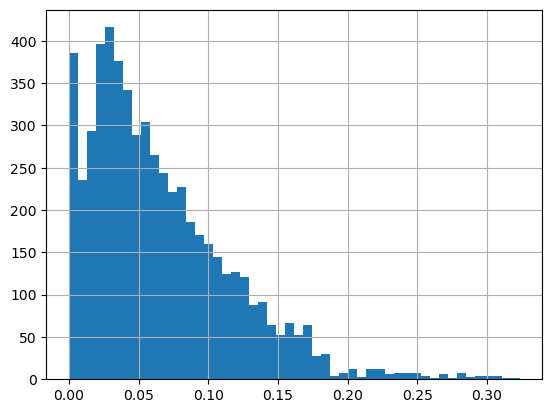

In [174]:
bigmart['Item_Visibility'].hist(bins = 50)
plt.show()

We see that its right skewed distribution.In this case we can take the root or apply log function.Lets try using a square root

In [175]:
item_visibility_squareroot = np.sqrt(bigmart['Item_Visibility'])

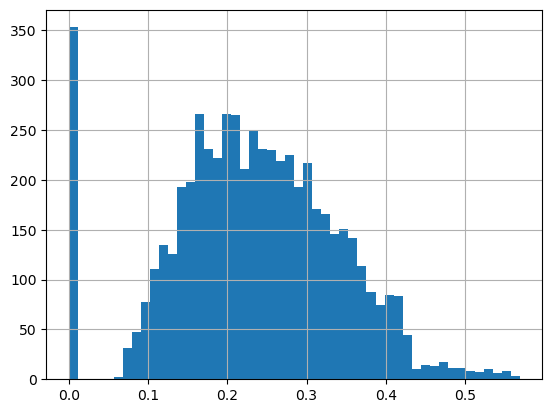

In [176]:
item_visibility_squareroot.hist(bins = 50)
plt.show()

**The resultant is a normal distributionn.Now lets use the log function**

In [177]:
item_visibility_log = np.log(bigmart['Item_Visibility'])


c:\Users\divya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


**This shows a warning-'divide by zero encountering in log'.Lets look ata the range of the values in the visibility coumn**

In [178]:
bigmart['Item_Visibility'].describe()

count    5681.000000
mean        0.065684
std         0.051252
min         0.000000
25%         0.027047
50%         0.054154
75%         0.093463
max         0.323637
Name: Item_Visibility, dtype: float64

**The minimum value we have is 0,and log(0) is not defined.Thus its showing us an error,So lets add 0.1 to each value and then take the log**

In [179]:
item_visisbity_log = np.log(bigmart['Item_Visibility']+0.1)
item_visibility_log = item_visibility_log.replace([np.inf, -np.inf],np.nan)
item_visibility_log = item_visibility_log.dropna()

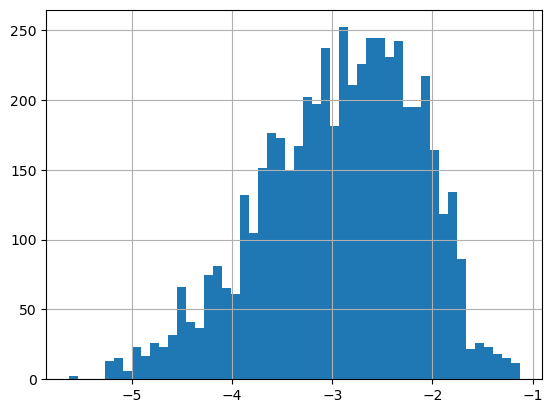

In [180]:
item_visibility_log.hist(bins=50)
plt.show()

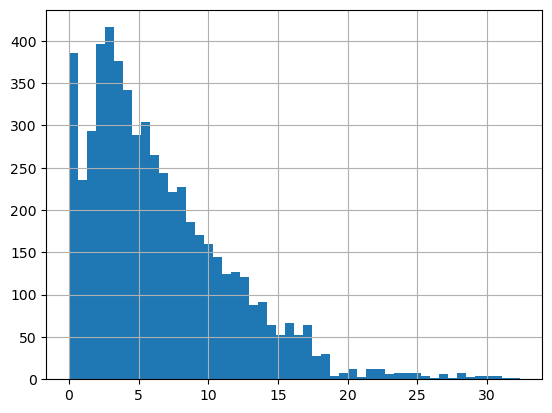

In [181]:
visibility = bigmart['Item_Visibility']*100
visibility.hist(bins=50)
plt.show()

**Now taking the log**

In [182]:
log_visibility = np.log(visibility + 1)

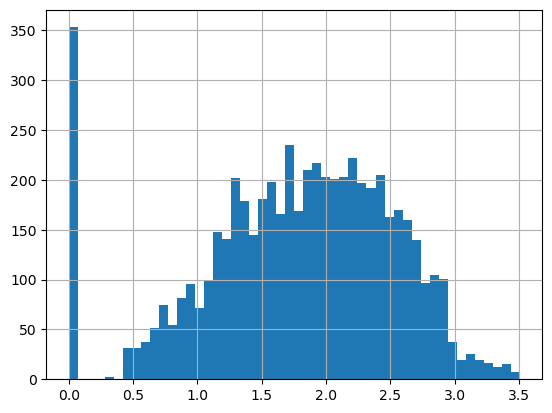

In [183]:
log_visibility.hist(bins = 50)
plt.show()

***MinMaxScaling***

In [184]:
from sklearn.preprocessing import MinMaxScaler

In [185]:
scaler = MinMaxScaler()
data = bigmart[['Item_Visibility','Item_MRP']]
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data,columns=['Item_Visibility','Item_MRP'])
scaled_data.head()

,Item_Visibility,Item_MRP
0,0.023374,0.323413
1,0.118737,0.235849
2,0.307674,0.894140
3,0.047548,0.524488
4,0.366458,0.862069


In [186]:
scaled_data.describe()

,Item_Visibility,Item_MRP
count,5681.000000,5681.000000
mean,0.202955,0.464766
std,0.158364,0.263468
min,0.000000,0.000000
25%,0.083572,0.266080
50%,0.167330,0.466437
75%,0.288788,0.656597
max,1.000000,1.000000


**Standard Scaler**

In [187]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_data = scaler.fit_transform(data)
scaler_data = pd.DataFrame(scaled_data,columns=['Item_Visibility','Item_MRP'])
scaler_data.head()


,Item_Visibility,Item_MRP
0,0.023374,0.323413
1,0.118737,0.235849
2,0.307674,0.894140
3,0.047548,0.524488
4,0.366458,0.862069


In [188]:
scaler_data.describe()

,Item_Visibility,Item_MRP
count,5681.000000,5681.000000
mean,0.202955,0.464766
std,0.158364,0.263468
min,0.000000,0.000000
25%,0.083572,0.266080
50%,0.167330,0.466437
75%,0.288788,0.656597
max,1.000000,1.000000


**One Hot Encoding**

In [189]:
bigmart = pd.read_csv('Train_bm_bignart.csv')

In [190]:
bigmart.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3


In [191]:
bigmart.shape

(5681, 10)

In [192]:
bigmart.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
dtype: object

In [193]:
bigmart['Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT027    624
OUT013    621
OUT035    620
OUT049    620
OUT046    620
OUT045    619
OUT018    618
OUT017    617
OUT010    370
OUT019    352
Name: count, dtype: int64

In [194]:
pd.get_dummies(bigmart['Outlet_Identifier'],dtype=int).head()

,OUT010,OUT013,OUT017,OUT018,OUT019,OUT027,OUT035,OUT045,OUT046,OUT049
0,0,0,0,0,0,0,0,0,0,1
1,0,0,1,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0


**Ding it for all variables**

In [195]:
bigmart_encoding = pd.get_dummies(bigmart,dtype=int)
bigmart_encoding.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Identifier_DRA12,Item_Identifier_DRA24,Item_Identifier_DRA59,Item_Identifier_DRB01,Item_Identifier_DRB13,Item_Identifier_DRB24,...,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3
0,20.750,0.007565,107.8622,1999,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0
1,8.300,0.038428,87.3198,2007,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,14.600,0.099575,241.7538,1998,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,7.315,0.015388,155.0340,2007,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,NaN,0.118599,234.2300,1985,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


****We have 2 problem****

*****Problem 1******

**look at a newlly created variables 'Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small',the order between theses variables is destroyed .As a result we are missing out on some important information**

In [196]:
bigmart_encoding[['Outlet_Size_High','Outlet_Size_Medium','Outlet_Size_Small']]

,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small
0,0,1,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,1,0
...,...,...,...
5676,0,0,1
5677,0,1,0
5678,0,0,0
5679,0,0,0


***Problem 2***

**The number of features has increased from 12 to 1584,Where maximax values are 0**

In [197]:
bigmart_encoding.shape

(5681, 1584)

*****Problem 1 solution*****

***Label encoding***

In [198]:
from sklearn.preprocessing import LabelEncoder

In [199]:
bigmart['Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT027    624
OUT013    621
OUT035    620
OUT049    620
OUT046    620
OUT045    619
OUT018    618
OUT017    617
OUT010    370
OUT019    352
Name: count, dtype: int64

In [200]:
le = LabelEncoder()
le.fit_transform(['Small','Medium','High'])

array([2, 1, 0])

**Label encoding uses the alphabetical order that might not be looking for everytime so thats why we use map**

In [201]:
bigmart['Outlet_Identifier'] = bigmart['Outlet_Identifier'].map({
    'Small':0,
    'Medium':1,
    'High':2
})


**Combine Sparse Class**

***Problem 2 solution***

In [202]:
bigmart.nunique()

Item_Identifier              1543
Item_Weight                   410
Item_Fat_Content                5
Item_Visibility              5277
Item_Type                      16
Item_MRP                     4402
Outlet_Identifier               0
Outlet_Establishment_Year       9
Outlet_Size                     3
Outlet_Location_Type            3
dtype: int64

In [203]:
temp = bigmart['Item_Identifier'].value_counts()
temp.head()

Item_Identifier
FDQ60    8
NCS41    8
FDW10    8
DRF48    8
FDN52    8
Name: count, dtype: int64

In [204]:
bigmart['Item_Identifier_count'] = bigmart['Item_Identifier'].apply(lambda x:temp[x])
bigmart[['Item_Identifier','Item_Identifier_count']].head()


,Item_Identifier,Item_Identifier_count
0,FDW58,7
1,FDW14,6
2,NCN55,4
3,FDQ58,3
4,FDY38,4


In [205]:
bigmart['Item_Identifier_count'] = bigmart['Item_Identifier_count'].astype(int)

In [206]:
for i in range(0,len(bigmart)):
    if bigmart['Item_Identifier_count'][i] < 4:
        bigmart['Item_Identifier'][i] = 'other'


C:\Users\divya\AppData\Local\Temp\ipykernel_23000\2937596438.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bigmart['Item_Identifier'][i] = 'other'
C:\Users\divya\AppData\Local\Temp\ipykernel_23000\2937596438.py:3: SettingWithCopyWarnin

In [207]:
bigmart.head(7)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Identifier_count
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,NaN,1999,Medium,Tier 1,7
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,NaN,2007,NaN,Tier 2,6
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,NaN,1998,NaN,Tier 3,4
3,other,7.315,Low Fat,0.015388,Snack Foods,155.0340,NaN,2007,NaN,Tier 2,3
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,NaN,1985,Medium,Tier 3,4
5,other,9.800,Regular,0.063817,Fruits and Vegetables,117.1492,NaN,1997,Small,Tier 1,3
6,other,19.350,Regular,0.082602,Baking Goods,50.1034,NaN,2009,Medium,Tier 3,2


In [208]:
bigmart['Item_Identifier'].value_counts()

Item_Identifier
other    1712
NCS41       8
FDK57       8
DRF48       8
FDN52       8
         ... 
FDU59       4
FDS49       4
FDX03       4
FDC35       4
FDF44       4
Name: count, Length: 832, dtype: int64

***Feature Generation****

In [209]:
stroke_data = pd.read_csv('smart_healthcare_dataset.csv')

In [210]:
stroke_data.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


***fetch_openml***

In [211]:
from sklearn.datasets import fetch_openml

In [215]:
data = fetch_openml(name='Titanic',version = 1,as_frame=True)

In [216]:
X,y =data['data'],data['target']

In [217]:
X

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


**label encoding**

In [218]:
from sklearn.preprocessing import LabelEncoder

In [219]:
le = LabelEncoder()
X['embarked_label-encoded'] = le.fit_transform(X['embarked'])

In [220]:
X.sample(5)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,embarked_label-encoded
1262,3,"van Billiard, Master. James William",male,NaN,1,1,A/5. 851,14.5000,NaN,S,NaN,NaN,NaN,2
638,3,"Asim, Mr. Adola",male,35.0,0,0,SOTON/O.Q. 3101310,7.0500,NaN,S,NaN,NaN,NaN,2
1088,3,"Olsson, Mr. Oscar Wilhelm",male,32.0,0,0,347079,7.7750,NaN,S,A,NaN,NaN,2
728,3,"Cook, Mr. Jacob",male,43.0,0,0,A/5 3536,8.0500,NaN,S,NaN,NaN,NaN,2
772,3,"Dika, Mr. Mirko",male,17.0,0,0,349232,7.8958,NaN,S,NaN,NaN,NaN,2


**Ordinal encoder**

for values in inheret order

In [221]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:


# convert string 'nan' to actual NaN
X['embarked'] = X['embarked'].replace('nan', np.nan)

# fill missing values
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])

# verify
print(X['embarked'].isnull().sum())


0


In [243]:
oe = OrdinalEncoder(categories=[['S','C','Q']])
X['embarked_ordinal-encoded'] = oe.fit_transform(X[['embarked']])


In [244]:
X.sample(5)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,embarked_label-encoded,embarked_ordinal-encoded
857,3,"Hedman, Mr. Oskar Arvid",male,27.0,0,0,347089,6.9750,NaN,S,15,NaN,NaN,2,0.0
1093,3,"Osen, Mr. Olaf Elon",male,16.0,0,0,7534,9.2167,NaN,S,NaN,NaN,NaN,2,0.0
350,2,"Brown, Miss. Edith Eileen",female,15.0,0,2,29750,39.0000,NaN,S,14,NaN,"Cape Town, South Africa / Seattle, WA",2,0.0
526,2,"Pallas y Castello, Mr. Emilio",male,29.0,0,0,SC/PARIS 2147,13.8583,NaN,C,9,NaN,"Spain / Havana, Cuba",0,1.0
690,3,"Brobeck, Mr. Karl Rudolf",male,22.0,0,0,350045,7.7958,NaN,S,NaN,NaN,"Sweden Worcester, MA",2,0.0


***One Hot Encoding***

In [245]:
X = X.join(pd.get_dummies(X['embarked'],dtype='int32',prefix='embarked'))

In [246]:
X.sample(5)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,embarked_label-encoded,embarked_ordinal-encoded,embarked_C,embarked_Q,embarked_S
221,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C,NaN,234.0,"Providence, RI",0,1.0,1,0,0
308,1,"White, Mrs. John Stuart (Ella Holmes)",female,55.0,0,0,PC 17760,135.6333,C32,C,8,NaN,"New York, NY / Briarcliff Manor NY",0,1.0,1,0,0
1019,3,"Mineff, Mr. Ivan",male,24.0,0,0,349233,7.8958,NaN,S,NaN,NaN,NaN,2,0.0,0,0,1
257,1,"Schabert, Mrs. Paul (Emma Mock)",female,35.0,1,0,13236,57.7500,C28,C,11,NaN,"New York, NY",0,1.0,1,0,0
993,3,"Mannion, Miss. Margareth",female,NaN,0,0,36866,7.7375,NaN,Q,16,NaN,NaN,1,2.0,0,1,0


**Binary Encoding**

In [247]:
!pip install category_encoders

In [248]:
import category_encoders as co

In [251]:
binary_encoders = co.BinaryEncoder()
binary_encoders = binary_encoders.fit_transform(X['embarked'])
X = pd.concat([X,binary_encoders],axis = 1)

In [252]:
X.sample(5)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,embarked_label-encoded,embarked_ordinal-encoded,embarked_C,embarked_Q,embarked_S,embarked_0,embarked_1
422,2,"Gill, Mr. John William",male,24.0,0,0,233866,13.0000,NaN,S,NaN,155.0,"Clevedon, England",2,0.0,0,0,1,0,1
1215,3,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q,NaN,NaN,NaN,1,2.0,0,1,0,1,1
41,1,"Brown, Mrs. James Joseph (Margaret Tobin)",female,44.0,0,0,PC 17610,27.7208,B4,C,6,NaN,"Denver, CO",0,1.0,1,0,0,1,0
350,2,"Brown, Miss. Edith Eileen",female,15.0,0,2,29750,39.0000,NaN,S,14,NaN,"Cape Town, South Africa / Seattle, WA",2,0.0,0,0,1,0,1
705,3,"Caram, Mr. Joseph",male,NaN,1,0,2689,14.4583,NaN,C,NaN,NaN,"Ottawa, ON",0,1.0,1,0,0,1,0


**Frequency Encoding**